# LFM Semantic Segmentation Workflow -- Data Cube Input
This notebook is an example workflow of doing semantic segmentation on visible light, UV, and static bands of Lunar data, using the 512x512 pixel "datacubes", generated by the Pipeline workflow. 

## Purpose of this notebook
This notebook is designed to be used after semantic segmentation training has been run (see semantic_seg_train.ipynb in the repo). Once you have run that, a checkpoint model will be saved to your disk (should be saved under {path/to/your/repo}/lfm/notebooks/outputs/sem_seg/checkpoints by default). Find the path to the best model checkpoint (usually called "best_model.pt"), and put the full path value in the config section below (variable is called "pretrained_checkpoint"). Once you have this, configure the other variables as you desire (comments in the cell can guide you), and run the rest of the notebook!

## Getting started

### Downloading
You can get started with this notebook by downloading it with:

```bash
wget https://raw.githubusercontent.com/nasa-nccs-hpda/lfm/refs/heads/main/notebooks/cube_inference_sseg.ipynb
```

### Code dependencies -- terminal command
The notebook requires some code from the [LFM repo](https://github.com/nasa-nccs-hpda/lfm/tree/main). To install this code, navigate to the top of the JupyterHub user interface, and click on the box with the + symbol. Then scroll down, and choose the "Terminal" (under Other section, first option). 

Then, if it's your first time using any of the LFM notebooks, run:

```bash
cd path/to/lfm/notebooks
git clone https://github.com/nasa-nccs-hpda/lfm.git
```

Or, if you've already run the above command, run:

```bash
cd path/to/lfm/notebooks
git pull https://github.com/nasa-nccs-hpda/lfm/tree/main
```

This will get you the most up-to-date code to support the notebook. 

### Python installs
You will notice 2 folders below that install dependencies for you; one removes your "local python installs", and the other installs things locally. **This is completely harmless, and don't worry about anything important getting deleted**. Local installs are very easy to get back using pip or conda, we are just deleting previous installs here to make sure we have a clean environment to work with. 

**See the README in the [repo](https://github.com/nasa-nccs-hpda/lfm)** for more info on how to use this notebook, and more on the process of training the model. 

# Setup

In [1]:
!rm -rf ~/.local/lib/python*

In [2]:
!pip install xarray tiler rioxarray transformers torchmetrics # For H100 system

Defaulting to user installation because normal site-packages is not writeable
  Using cached xarray-2026.4.0-py3-none-any.whl.metadata (12 kB)
  Using cached tiler-0.6.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached rioxarray-0.22.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached rasterio-1.5.0-cp312-cp312-manylinux_2_28_aarch64.whl.metadata (8.6 kB)
  Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_aarch64.whl.metadata (31 kB)
INFO: pip is looking at multiple versions of rioxarray to determine which version is compatible with other requirements. This could take a while.
  Using cached rioxarray-0.21.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached xarray-2025.11.0-py3-none-any.whl.metadata (12 kB)
  Using cached rioxarray-0.20.0-py3-none-any.whl.metadata (5.4 kB)
  Using c

In [3]:
# Standard library imports
import os
import subprocess
import sys
from datetime import datetime
from glob import glob
from pathlib import Path

# Third-party imports
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import torch
import xarray as xr
from tqdm import tqdm
from tiler import Tiler, Merger

%matplotlib inline

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
repo_dir = "lfm"
sys.path.insert(0, os.path.join(os.getcwd(), repo_dir))

from lfm.tasks.sem_segmentation.sseg_model import load_dinov3_encoder, DINOSegmentation
from lfm.tasks.sem_segmentation.data_cube_inference import run_datacube_inference

Installing termcolor (required by DINOv3)...
✓ Termcolor installed successfully


# Config

In [5]:
# Data paths
INPUT_DIR = "/explore/nobackup/projects/lfm/model_inputs/data_cubes/WAC_STATIC"

# Where to load dinov3 init weights, and where to load the trained model weights
weights_local_checkpoint = '/explore/nobackup/projects/lfm/model_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth'
pretrained_checkpoint = "/explore/nobackup/projects/lfm/model_inference/checkpoints/sem_seg/12_band/checkpoint_epoch_100_NO_ZSCORE.pt"

# Output dir (this will be created automatically)
OUTPUT_DIR = Path("./outputs/cube_inference")  # Change this if you want a specific path
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
print(f"Output directory: {OUTPUT_DIR}")

# Training hyperparameters
BATCH_SIZE = 16
NUM_WORKERS = 8

# Number of bands, band filter
NUM_BANDS = 12  # n bands to be passed through model; NOT n bands in base input!
BAND_FILTER = None  # UV bands are first 2, RGB are bands 5, 3, 2

# Model parameters
TARGET_SIZE = (304, 304)  # Input size for DINO model

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Output directory: outputs/cube_inference
Using device: cuda


# Load model

In [6]:
# Load model from model factory
encoder = load_dinov3_encoder(weights_local_checkpoint, device=device)
model = DINOSegmentation(
    encoder=encoder,  # Use DINOv3 head
    num_classes=2,  # Binary segmentaton (crater, not crater)
    img_size=TARGET_SIZE,
    num_bands=NUM_BANDS,
).to(device)

# Apply checkpoint
checkpoint = torch.load(pretrained_checkpoint, map_location='cpu')
checkpoint_state = checkpoint['model_state_dict']
missing_keys, unexpected_keys = model.load_state_dict(
    checkpoint_state, strict=False
)
model.to(device)
model.eval()
print("Successfully loaded model from checkpoint!")

Loading model from /explore/nobackup/projects/lfm/model_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth


Using cache found in /home/ajkerr1/.cache/torch/hub/facebookresearch_dinov3_main


Encoder loaded with pretrained weights.
Modifying input weights for > 3 bands...
Applied flexible embedding approach to match input bands. Bands specified: 12
Successfully loaded model from checkpoint!


# Load data

## Load statistics from training to normalize inputs

In [7]:
print("\n" + "="*60)
print("STEP 1: Loading training dataset statistics...")

# Load mean and std from a previous training run
MEAN = np.load("/explore/nobackup/projects/lfm/model_inference/stats/sem_seg/12_band/dataset_mean.npy")
STD = np.load("/explore/nobackup/projects/lfm/model_inference/stats/sem_seg/12_band/dataset_std.npy")

print("Done.")
print(f"Mean: {MEAN},\nSTD: {STD}")
print("="*60)


STEP 1: Loading training dataset statistics...
Done.
Mean: [0.33754832 0.35187309 0.35549115 0.35850178 0.36156565 0.39414871
 0.39244862 0.50912056 0.4963789  0.5656259  0.48777842 0.19440428],
STD: [0.11732978 0.1224788  0.12259223 0.12308919 0.12270314 0.17081498
 0.17012271 0.19779165 0.26302737 0.22913534 0.26093758 0.18329036]


# Inference

Loading up to 10 datacubes from TIFF files...
Raw datacubes shape: (8, 12, 512, 512)
Transposed to: (8, 512, 512, 12)

Applying min-max scaling per band...
(512, 512, 12)
(512, 512, 12)
(512, 512, 12)
(512, 512, 12)
(512, 512, 12)
(512, 512, 12)
(512, 512, 12)
(512, 512, 12)
After scaling: min=0.000, max=1.000

Running inference with tile visualization: False


Processing image 1/8
Number of tiles: 16
Tile overlap: 75% (228 pixels)


100%|██████████| 16/16 [00:04<00:00,  3.74 batches/s]


Merged probabilities shape: (512, 512, 1)
Merged prob range: [0.0000, 0.9994]
Final prediction shape: (512, 512)
Prediction range: [0.00, 1.00]
Positive pixels: 18019 / 262144

Processing image 2/8
Number of tiles: 16
Tile overlap: 75% (228 pixels)


100%|██████████| 16/16 [00:00<00:00, 38.34 batches/s]


Merged probabilities shape: (512, 512, 1)
Merged prob range: [0.0000, 0.9999]
Final prediction shape: (512, 512)
Prediction range: [0.00, 1.00]
Positive pixels: 668 / 262144

Processing image 3/8
Number of tiles: 16
Tile overlap: 75% (228 pixels)


...

100%|██████████| 16/16 [00:00<00:00, 35.35 batches/s]


Merged probabilities shape: (512, 512, 1)
Merged prob range: [0.0000, 0.9907]
Final prediction shape: (512, 512)
Prediction range: [0.00, 1.00]
Positive pixels: 92926 / 262144

Processing image 8/8
Number of tiles: 16
Tile overlap: 75% (228 pixels)


100%|██████████| 16/16 [00:00<00:00, 43.63 batches/s]


Merged probabilities shape: (512, 512, 1)
Merged prob range: [0.0000, 0.9947]
Final prediction shape: (512, 512)
Prediction range: [0.00, 1.00]
Positive pixels: 60202 / 262144

Got predictions

Creating visualization...


NameError: name 'thresh' is not defined

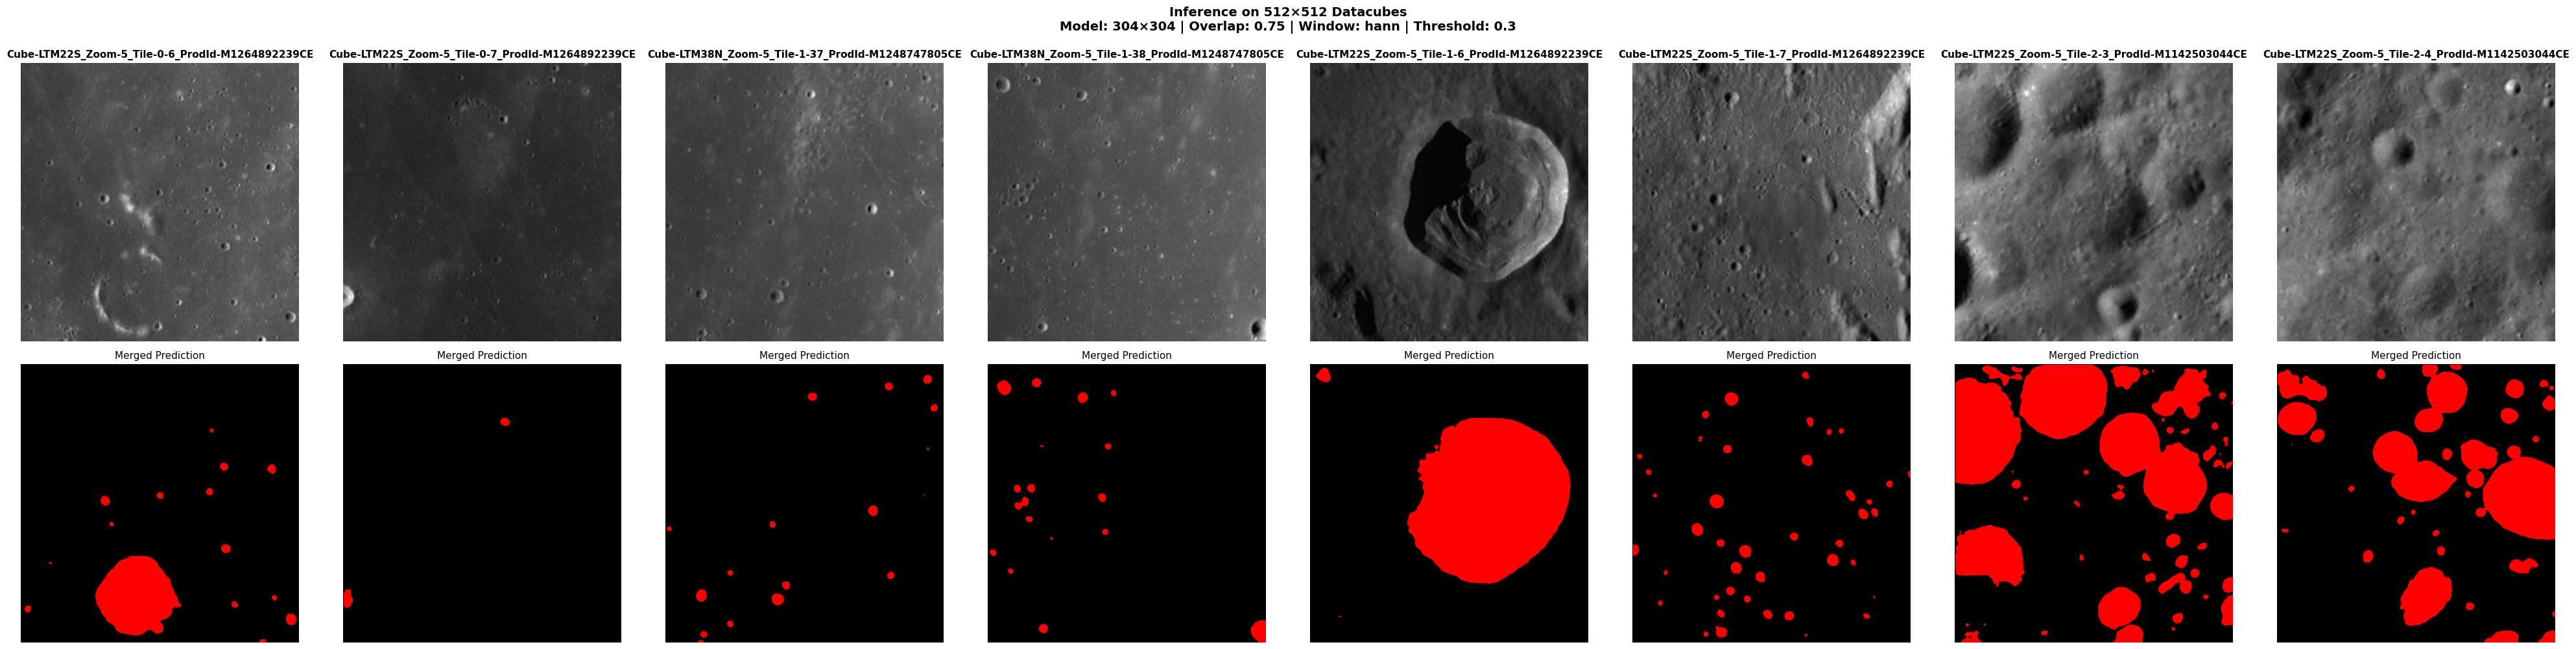

In [8]:
n_images = 10
overlap = 0.75
thresh = 0.3

images, preds = run_datacube_inference(
    model=model,
    device=device,
    input_dir=INPUT_DIR,
    mean=MEAN,
    std=STD,
    output_dir=OUTPUT_DIR,
    n_images=n_images,
    model_native_size=TARGET_SIZE[0],
    tile_overlap=overlap,
    threshold=thresh,
    save_inputs_dir=None,
    debug=False,
    tile_window='hann',
    visualize_tiles=False
)